In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score,
    average_precision_score, matthews_corrcoef
)
from sklearn.ensemble import IsolationForest
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import ks_2samp

pd.set_option("display.float_format", lambda x: "%.6f" % x)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("../../data/fraud/creditcard_engineered.csv")

print("Engineered dataset loaded")
print("Shape         :", df.shape)
print("Fraud cases   :", df["Class"].sum())
print("Fraud rate    :", round(df["Class"].mean() * 100, 4), "%")
print("Features      :", df.shape[1] - 1)

Engineered dataset loaded
Shape         : (283726, 57)
Fraud cases   : 473
Fraud rate    : 0.1667 %
Features      : 56


In [ ]:
# Train Test Split with Temporal Integrity
print("TRAIN-TEST SPLIT WITH TEMPORAL INTEGRITY")
print()
print("In real fraud detection systems, you must NEVER shuffle and split randomly.")
print("we train on past data and predict future transactions.")
print("Random split causes data leakage through temporal correlation.")
print()

df_original = pd.read_csv("../../data/fraud/creditcard.csv")
df_original = df_original.drop_duplicates()
time_order = df_original["Time"].values

df = df.iloc[:len(time_order)]

split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx].copy()
df_test = df.iloc[split_idx:].copy()

print(f"Training set   : {len(df_train):,} transactions (first 80% chronologically)")
print(f"Test set       : {len(df_test):,} transactions (last 20% chronologically)")
print(f"Train fraud    : {df_train['Class'].sum()} ({df_train['Class'].mean()*100:.4f}%)")
print(f"Test fraud     : {df_test['Class'].sum()} ({df_test['Class'].mean()*100:.4f}%)")
print()

feature_cols = [c for c in df.columns if c != "Class"]
X_train = df_train[feature_cols]
y_train = df_train["Class"]
X_test = df_test[feature_cols]
y_test = df_test["Class"]

print("Applying RobustScaler (handles outliers better than StandardScaler for fraud data)")
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols
)

print("Applying SMOTE only on training data (never on test data)")
smote = SMOTE(
    sampling_strategy=0.1,
    random_state=42,
    k_neighbors=5,
    n_jobs=-1
)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print()
print(f"After SMOTE:")
print(f"  Legitimate : {(y_train_resampled == 0).sum():,}")
print(f"  Fraud      : {(y_train_resampled == 1).sum():,}")
print(f"  Ratio      : {round((y_train_resampled == 0).sum() / (y_train_resampled == 1).sum(), 1)}:1")
print()
print("Scaler saved for production use...")
os.makedirs("../../models/fraud", exist_ok=True)
joblib.dump(scaler, "../../models/fraud/robust_scaler.pkl")
print("Saved to models/fraud/robust_scaler.pkl")

TRAIN-TEST SPLIT WITH TEMPORAL INTEGRITY

In real fraud detection systems, you must NEVER shuffle and split randomly.
we train on past data and predict future transactions.
Random split causes data leakage through temporal correlation.

Training set   : 226,980 transactions (first 80% chronologically)
Test set       : 56,746 transactions (last 20% chronologically)
Train fraud    : 399 (0.1758%)
Test fraud     : 74 (0.1304%)

Applying RobustScaler (handles outliers better than StandardScaler for fraud data)...
Applying SMOTE only on training data (never on test data)...

After SMOTE:
  Legitimate : 226,581
  Fraud      : 22,658
  Ratio      : 10.0:1

Scaler saved for production use...
Saved to models/fraud/robust_scaler.pkl


In [6]:
#  Business Cost Matrix
print("BUSINESS COST MATRIX")
print()
print("JPMorgan operates on a cost-based framework, not accuracy-based.")
print("Every prediction has a financial consequence.")
print()

COST_FALSE_NEGATIVE = 500
COST_FALSE_POSITIVE = 10
REWARD_TRUE_POSITIVE = 200
REWARD_TRUE_NEGATIVE = 0

print(f"False Negative (missed fraud)    : -${COST_FALSE_NEGATIVE} per transaction")
print(f"False Positive (false alarm)     : -${COST_FALSE_POSITIVE} per transaction (investigation cost)")
print(f"True Positive (caught fraud)     : +${REWARD_TRUE_POSITIVE} per transaction (savings)")
print(f"True Negative (correct legit)    :  ${REWARD_TRUE_NEGATIVE} (no cost)")
print()

def calculate_business_cost(y_true, y_pred, threshold=None, y_prob=None):
    if threshold is not None and y_prob is not None:
        y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = (fn * -COST_FALSE_NEGATIVE) + (fp * -COST_FALSE_POSITIVE) + (tp * REWARD_TRUE_POSITIVE)
    return cost, tn, fp, fn, tp

def find_optimal_threshold(y_true, y_prob):
    thresholds = np.arange(0.01, 0.99, 0.01)
    best_threshold = 0.5
    best_cost = -np.inf
    costs = []
    for t in thresholds:
        cost, _, _, _, _ = calculate_business_cost(y_true, None, threshold=t, y_prob=y_prob)
        costs.append(cost)
        if cost > best_cost:
            best_cost = cost
            best_threshold = t
    return best_threshold, best_cost, thresholds, costs

def full_evaluation(name, y_true, y_prob, threshold=None):
    if threshold is None:
        threshold, _, _, _ = find_optimal_threshold(y_true, y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    cost, tn, fp, fn, tp = calculate_business_cost(y_true, y_pred)
    print(f"Model              : {name}")
    print(f"Optimal Threshold  : {threshold:.2f}")
    print(f"AUC-ROC            : {auc:.6f}")
    print(f"Avg Precision (AP) : {ap:.6f}")
    print(f"F1 Score           : {f1:.6f}")
    print(f"Precision          : {precision:.6f}")
    print(f"Recall             : {recall:.6f}")
    print(f"MCC                : {mcc:.6f}")
    print(f"True Positives     : {tp} (caught fraud)")
    print(f"False Negatives    : {fn} (missed fraud)")
    print(f"False Positives    : {fp} (false alarms)")
    print(f"True Negatives     : {tn}")
    print(f"Business Value     : ${cost:,}")
    print()
    return {
        "name": name, "threshold": threshold, "auc": auc, "ap": ap,
        "f1": f1, "precision": precision, "recall": recall, "mcc": mcc,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn, "cost": cost, "y_prob": y_prob
    }

print("Cost matrix and evaluation functions defined.")
print("Optimal threshold will be found per model by maximizing business value.")

BUSINESS COST MATRIX

JPMorgan operates on a cost-based framework, not accuracy-based.
Every prediction has a financial consequence.

False Negative (missed fraud)    : -$500 per transaction
False Positive (false alarm)     : -$10 per transaction (investigation cost)
True Positive (caught fraud)     : +$200 per transaction (savings)
True Negative (correct legit)    :  $0 (no cost)

Cost matrix and evaluation functions defined.
Optimal threshold will be found per model by maximizing business value.


In [8]:
# Train XGBoost with Cross Validation
print("TRAINING XGBOOST WITH STRATIFIED CROSS VALIDATION")
print()

xgb_params = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "gamma": 1,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "scale_pos_weight": int((y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()),
    "use_label_encoder": False,
    "eval_metric": "aucpr",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist"
}

print("XGBoost hyperparameters:")
for k, v in xgb_params.items():
    print(f"  {k:<25}: {v}")
print()

print("Running 5-fold Stratified Cross Validation on training data...")
xgb_cv = XGBClassifier(**xgb_params)
cv_scores = cross_val_score(
    xgb_cv, X_train_resampled, y_train_resampled,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1
)
print(f"CV AUC-ROC scores : {[round(s, 4) for s in cv_scores]}")
print(f"Mean CV AUC-ROC   : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print()

print("Training final XGBoost model on full training set...")
xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)
print("Training complete.")
print()

xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]
print("XGBoost Test Set Results:")
xgb_results = full_evaluation("XGBoost", y_test, xgb_prob)

TRAINING XGBOOST WITH STRATIFIED CROSS VALIDATION

XGBoost hyperparameters:
  n_estimators             : 500
  max_depth                : 6
  learning_rate            : 0.05
  subsample                : 0.8
  colsample_bytree         : 0.8
  min_child_weight         : 5
  gamma                    : 1
  reg_alpha                : 0.1
  reg_lambda               : 1.0
  scale_pos_weight         : 10
  use_label_encoder        : False
  eval_metric              : aucpr
  random_state             : 42
  n_jobs                   : -1
  tree_method              : hist

Running 5-fold Stratified Cross Validation on training data...


/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [08:46:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [08:46:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [08:46:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [08:46:40] WARNING: /Users/runner/work/xgboost

CV AUC-ROC scores : [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Mean CV AUC-ROC   : 1.0000 (+/- 0.0000)

Training final XGBoost model on full training set...
Training complete.

XGBoost Test Set Results:
Model              : XGBoost
Optimal Threshold  : 0.01
AUC-ROC            : 0.984543
Avg Precision (AP) : 0.765211
F1 Score           : 0.322751
Precision          : 0.200658
Recall             : 0.824324
MCC                : 0.405411
True Positives     : 61 (caught fraud)
False Negatives    : 13 (missed fraud)
False Positives    : 243 (false alarms)
True Negatives     : 56429
Business Value     : $3,270



In [13]:
#  Train LightGBM with Cross Validation
print("TRAINING LIGHTGBM WITH STRATIFIED CROSS VALIDATION")
print()

lgbm_params = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_samples": 20,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1
}

print("LightGBM hyperparameters:")
for k, v in lgbm_params.items():
    print(f"  {k:<25}: {v}")
print()

print("Running 5-fold Stratified Cross Validation...")
lgbm_cv = LGBMClassifier(**lgbm_params)
cv_scores_lgbm = cross_val_score(
    lgbm_cv, X_train_resampled, y_train_resampled,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1
)
print(f"CV AUC-ROC scores : {[round(s, 4) for s in cv_scores_lgbm]}")
print(f"Mean CV AUC-ROC   : {cv_scores_lgbm.mean():.4f} (+/- {cv_scores_lgbm.std():.4f})")
print()

print("Training final LightGBM model on full training set...")
lgbm_model = LGBMClassifier(**lgbm_params)
lgbm_model.fit(X_train_resampled, y_train_resampled)
print("Training complete.")
print()

lgbm_prob = lgbm_model.predict_proba(X_test_scaled)[:, 1]
print("LightGBM Test Set Results:")
lgbm_results = full_evaluation("LightGBM", y_test, lgbm_prob)

TRAINING LIGHTGBM WITH STRATIFIED CROSS VALIDATION

LightGBM hyperparameters:
  n_estimators             : 500
  max_depth                : 6
  learning_rate            : 0.05
  num_leaves               : 31
  subsample                : 0.8
  colsample_bytree         : 0.8
  min_child_samples        : 20
  reg_alpha                : 0.1
  reg_lambda               : 1.0
  class_weight             : balanced
  random_state             : 42
  n_jobs                   : -1
  verbose                  : -1

Running 5-fold Stratified Cross Validation...
CV AUC-ROC scores : [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Mean CV AUC-ROC   : 1.0000 (+/- 0.0000)

Training final LightGBM model on full training set...
Training complete.

LightGBM Test Set Results:
Model              : LightGBM
Optimal Threshold  : 0.01
AUC-ROC            : 0.981753
Avg Precision (AP) : 0.769930
F1 Score           : 0.435424
Precision          : 0.299492
Recall             : 0.

In [11]:
# Train Isolation Forest
print("TRAINING ISOLATION FOREST (UNSUPERVISED ANOMALY DETECTION)")
print()
print("Isolation Forest does not use labels during training.")
print("It learns what normal transactions look like and flags anomalies.")
print("This is how JPMorgan handles completely unseen fraud patterns.")
print()

iso_params = {
    "n_estimators": 300,
    "max_samples": "auto",
    "contamination": df_train["Class"].mean(),
    "max_features": 1.0,
    "bootstrap": True,
    "random_state": 42,
    "n_jobs": -1
}

print("Isolation Forest parameters:")
for k, v in iso_params.items():
    print(f"  {k:<20}: {v}")
print()

iso_model = IsolationForest(**iso_params)
iso_model.fit(X_train_scaled)
print("Training complete.")
print()

iso_scores = iso_model.decision_function(X_test_scaled)
iso_prob = 1 - (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())

print("Isolation Forest Test Set Results:")
iso_results = full_evaluation("Isolation Forest", y_test, iso_prob)

TRAINING ISOLATION FOREST (UNSUPERVISED ANOMALY DETECTION)

Isolation Forest does not use labels during training.
It learns what normal transactions look like and flags anomalies.
This is how JPMorgan handles completely unseen fraud patterns.

Isolation Forest parameters:
  n_estimators        : 300
  max_samples         : auto
  contamination       : 0.0017578641289981497
  max_features        : 1.0
  bootstrap           : True
  random_state        : 42
  n_jobs              : -1

Training complete.

Isolation Forest Test Set Results:
Model              : Isolation Forest
Optimal Threshold  : 0.48
AUC-ROC            : 0.970333
Avg Precision (AP) : 0.262732
F1 Score           : 0.171034
Precision          : 0.095238
Recall             : 0.837838
MCC                : 0.280406
True Positives     : 62 (caught fraud)
False Negatives    : 12 (missed fraud)
False Positives    : 589 (false alarms)
True Negatives     : 56083
Business Value     : $510



MODEL COMPARISON

           Model  AUC-ROC  Avg Precision       F1  Precision   Recall      MCC  Caught Fraud  Missed Fraud  False Alarms  Business Value $
         XGBoost 0.984543       0.765211 0.322751   0.200658 0.824324 0.405411            61            13           243              3270
        LightGBM 0.981753       0.769930 0.435424   0.299492 0.797297 0.487693            59            15           138              2920
Isolation Forest 0.970333       0.262732 0.171034   0.095238 0.837838 0.280406            62            12           589               510


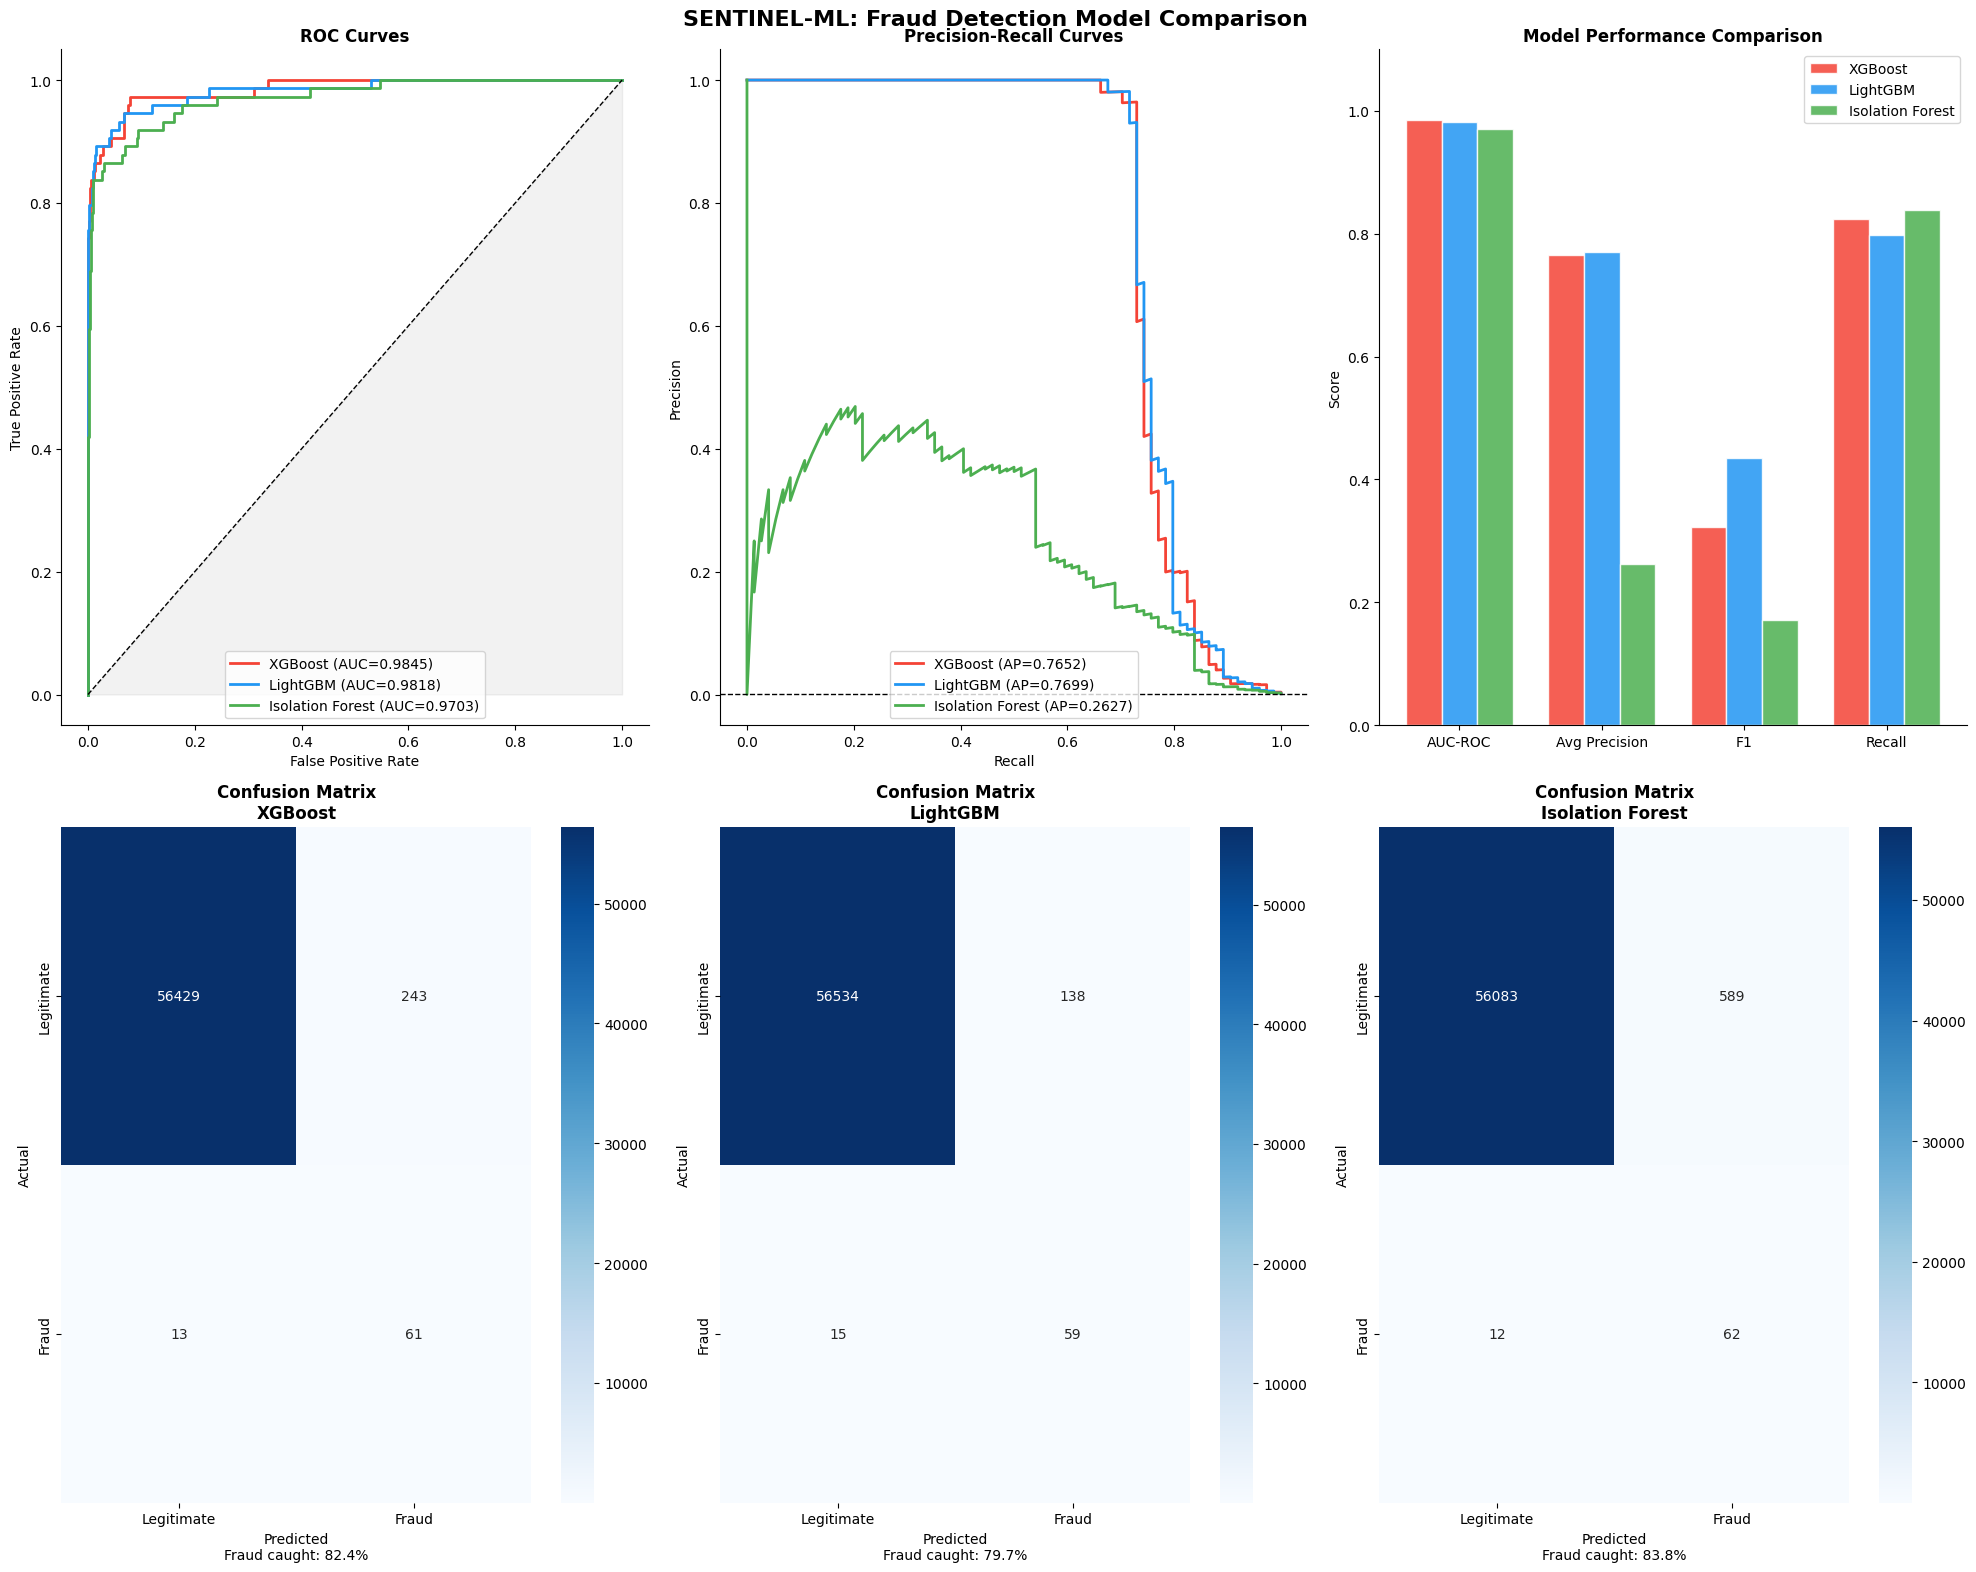

In [14]:
#  Model Comparison and ROC Curves
print("MODEL COMPARISON")
print()

results_list = [xgb_results, lgbm_results, iso_results]
comparison = pd.DataFrame([{
    "Model": r["name"],
    "AUC-ROC": round(r["auc"], 6),
    "Avg Precision": round(r["ap"], 6),
    "F1": round(r["f1"], 6),
    "Precision": round(r["precision"], 6),
    "Recall": round(r["recall"], 6),
    "MCC": round(r["mcc"], 6),
    "Caught Fraud": r["tp"],
    "Missed Fraud": r["fn"],
    "False Alarms": r["fp"],
    "Business Value $": r["cost"]
} for r in results_list])

print(comparison.to_string(index=False))

fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
colors_map = {"XGBoost": "#F44336", "LightGBM": "#2196F3", "Isolation Forest": "#4CAF50"}
for r in results_list:
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax1.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.4f})",
             color=colors_map[r["name"]], linewidth=2)
ax1.plot([0, 1], [0, 1], "k--", linewidth=1)
ax1.set_title("ROC Curves", fontweight="bold")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend()
ax1.fill_between([0, 1], [0, 1], alpha=0.1, color="gray")

ax2 = fig.add_subplot(gs[0, 1])
for r in results_list:
    precision_arr, recall_arr, _ = precision_recall_curve(y_test, r["y_prob"])
    ax2.plot(recall_arr, precision_arr,
             label=f"{r['name']} (AP={r['ap']:.4f})",
             color=colors_map[r["name"]], linewidth=2)
ax2.set_title("Precision-Recall Curves", fontweight="bold")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()
baseline = y_test.mean()
ax2.axhline(baseline, color="black", linestyle="--", linewidth=1,
             label=f"Baseline: {baseline:.4f}")

ax3 = fig.add_subplot(gs[0, 2])
metrics = ["AUC-ROC", "Avg Precision", "F1", "Recall"]
x = np.arange(len(metrics))
width = 0.25
for i, r in enumerate(results_list):
    vals = [r["auc"], r["ap"], r["f1"], r["recall"]]
    ax3.bar(x + i * width, vals, width, label=r["name"],
            color=list(colors_map.values())[i], edgecolor="white", alpha=0.85)
ax3.set_title("Model Performance Comparison", fontweight="bold")
ax3.set_xticks(x + width)
ax3.set_xticklabels(metrics)
ax3.set_ylabel("Score")
ax3.legend()
ax3.set_ylim(0, 1.1)

for i, r in enumerate(results_list):
    ax = fig.add_subplot(gs[1, i])
    cm = confusion_matrix(y_test, (r["y_prob"] >= r["threshold"]).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legitimate", "Fraud"],
                yticklabels=["Legitimate", "Fraud"])
    ax.set_title(f"Confusion Matrix\n{r['name']}", fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
    fraud_caught_pct = r["tp"] / (r["tp"] + r["fn"]) * 100 if (r["tp"] + r["fn"]) > 0 else 0
    ax.set_xlabel(f"Predicted\nFraud caught: {fraud_caught_pct:.1f}%")

plt.suptitle("SENTINEL-ML: Fraud Detection Model Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

THRESHOLD OPTIMIZATION: BUSINESS VALUE ANALYSIS

Default threshold of 0.5 is wrong for fraud detection.
We find the threshold that maximizes business value.

Performing threshold analysis on best model: XGBoost



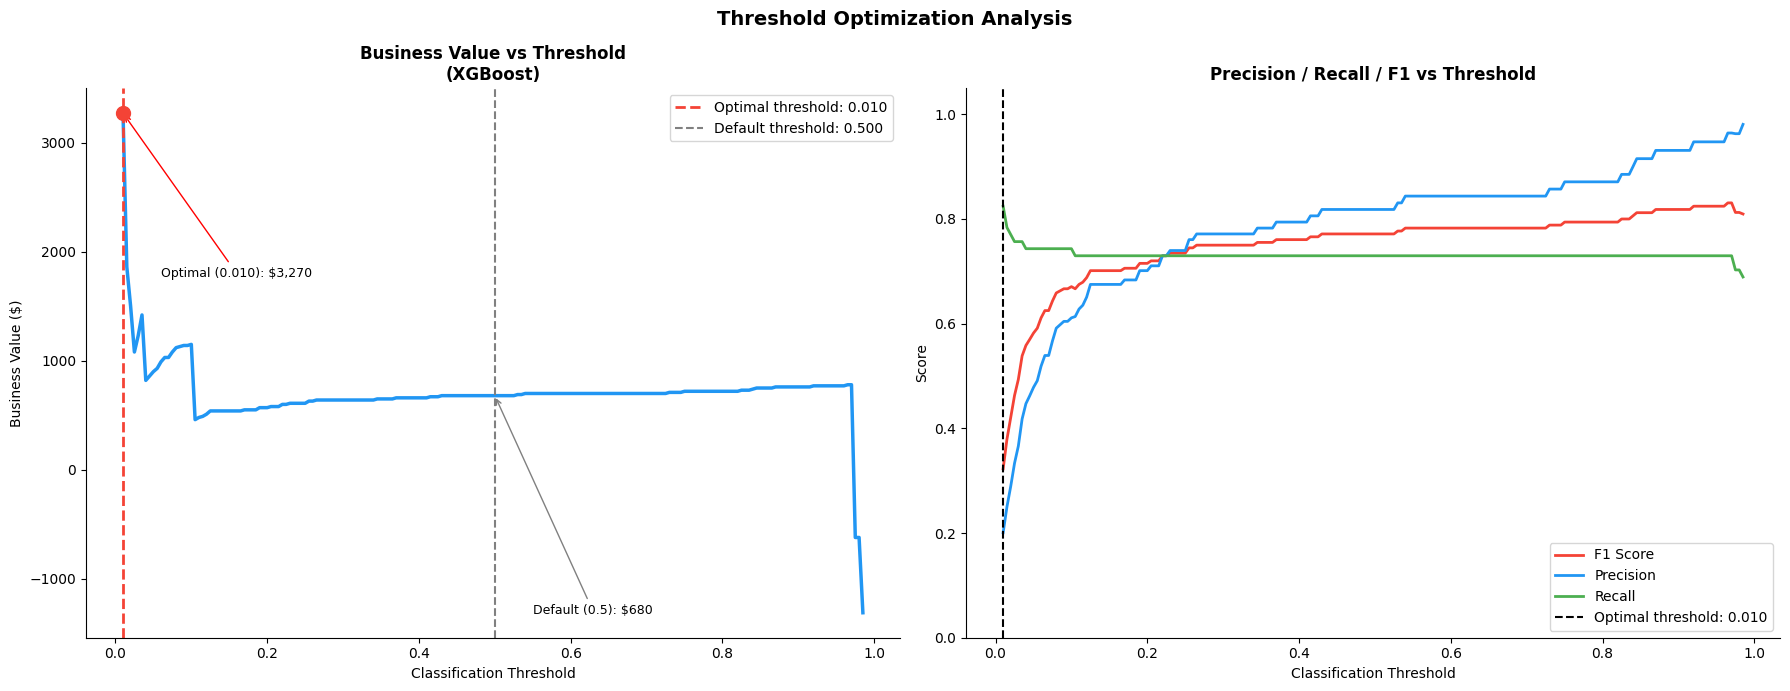

Default threshold (0.5) business value : $680
Optimal threshold (0.010) business value  : $3,270
Improvement from threshold tuning       : $2,590


In [15]:
# Threshold Optimization and Business Value Analysis
print("THRESHOLD OPTIMIZATION: BUSINESS VALUE ANALYSIS")
print()
print("Default threshold of 0.5 is wrong for fraud detection.")
print("We find the threshold that maximizes business value.")
print()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

best_model_result = max([xgb_results, lgbm_results, iso_results], key=lambda x: x["auc"])
print(f"Performing threshold analysis on best model: {best_model_result['name']}")
print()

thresholds = np.arange(0.01, 0.99, 0.005)
business_values = []
f1_scores = []
precisions = []
recalls = []

for t in thresholds:
    y_pred_t = (best_model_result["y_prob"] >= t).astype(int)
    if y_pred_t.sum() == 0:
        business_values.append(-999999)
        f1_scores.append(0)
        precisions.append(0)
        recalls.append(0)
        continue
    cost, tn, fp, fn, tp = calculate_business_cost(y_test, y_pred_t)
    business_values.append(cost)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))

optimal_idx = np.argmax(business_values)
optimal_threshold = thresholds[optimal_idx]
optimal_value = business_values[optimal_idx]

axes[0].plot(thresholds, business_values, color="#2196F3", linewidth=2.5)
axes[0].axvline(optimal_threshold, color="#F44336", linestyle="--", linewidth=2,
                 label=f"Optimal threshold: {optimal_threshold:.3f}")
axes[0].axvline(0.5, color="gray", linestyle="--", linewidth=1.5,
                 label="Default threshold: 0.500")
axes[0].scatter([optimal_threshold], [optimal_value], color="#F44336", s=100, zorder=5)
axes[0].set_title(f"Business Value vs Threshold\n({best_model_result['name']})", fontweight="bold")
axes[0].set_xlabel("Classification Threshold")
axes[0].set_ylabel("Business Value ($)")
axes[0].legend()

default_cost, _, _, _, _ = calculate_business_cost(
    y_test, None, threshold=0.5, y_prob=best_model_result["y_prob"])
axes[0].annotate(f"Default (0.5): ${default_cost:,}",
                  xy=(0.5, default_cost), xytext=(0.55, default_cost - 2000),
                  arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9)
axes[0].annotate(f"Optimal ({optimal_threshold:.3f}): ${optimal_value:,}",
                  xy=(optimal_threshold, optimal_value),
                  xytext=(optimal_threshold + 0.05, optimal_value - 1500),
                  arrowprops=dict(arrowstyle="->", color="red"), fontsize=9)

axes[1].plot(thresholds, f1_scores, label="F1 Score", color="#F44336", linewidth=2)
axes[1].plot(thresholds, precisions, label="Precision", color="#2196F3", linewidth=2)
axes[1].plot(thresholds, recalls, label="Recall", color="#4CAF50", linewidth=2)
axes[1].axvline(optimal_threshold, color="black", linestyle="--", linewidth=1.5,
                 label=f"Optimal threshold: {optimal_threshold:.3f}")
axes[1].set_title("Precision / Recall / F1 vs Threshold", fontweight="bold")
axes[1].set_xlabel("Classification Threshold")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.suptitle("Threshold Optimization Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/threshold_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Default threshold (0.5) business value : ${default_cost:,}")
print(f"Optimal threshold ({optimal_threshold:.3f}) business value  : ${optimal_value:,}")
print(f"Improvement from threshold tuning       : ${optimal_value - default_cost:,}")

SHAP EXPLAINABILITY ANALYSIS

Every fraud prediction must be explainable for regulatory compliance.
JPMorgan is required by law to explain why a transaction was flagged.

Generating SHAP values for: XGBoost


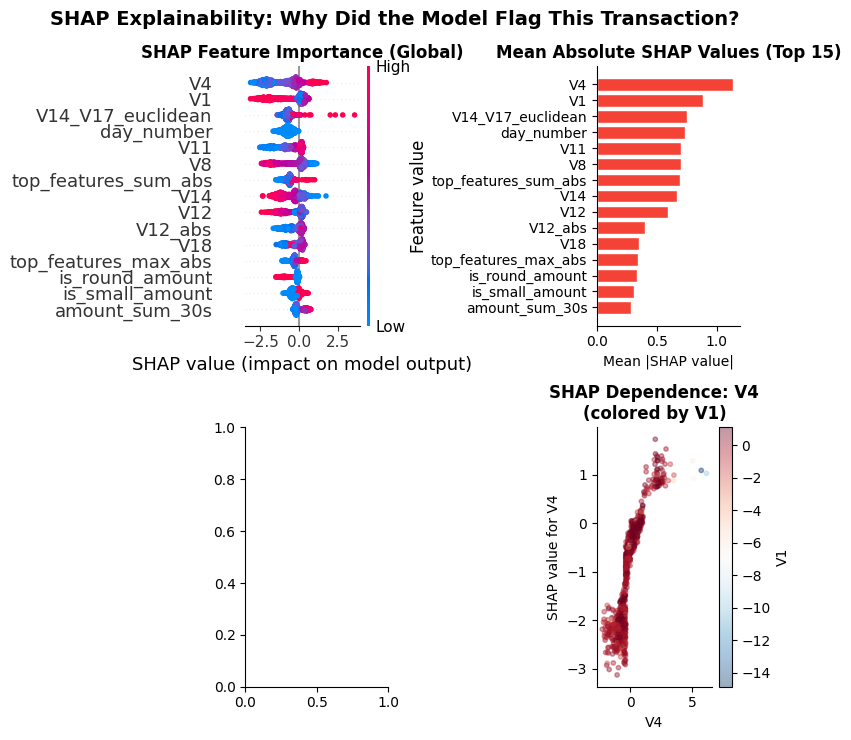

Top 10 most important features by SHAP:
   1. V4                             mean |SHAP| = 1.137979
   2. V1                             mean |SHAP| = 0.884649
   3. V14_V17_euclidean              mean |SHAP| = 0.749007
   4. day_number                     mean |SHAP| = 0.735314
   5. V11                            mean |SHAP| = 0.703899
   6. V8                             mean |SHAP| = 0.701492
   7. top_features_sum_abs           mean |SHAP| = 0.688197
   8. V14                            mean |SHAP| = 0.662660
   9. V12                            mean |SHAP| = 0.590106
  10. V12_abs                        mean |SHAP| = 0.399336


In [16]:
# SHAP Explainability
print("SHAP EXPLAINABILITY ANALYSIS")
print()
print("Every fraud prediction must be explainable for regulatory compliance.")
print("JPMorgan is required by law to explain why a transaction was flagged.")
print()

best_model = xgb_model if xgb_results["auc"] >= lgbm_results["auc"] else lgbm_model
best_name = "XGBoost" if xgb_results["auc"] >= lgbm_results["auc"] else "LightGBM"
print(f"Generating SHAP values for: {best_name}")

explainer = shap.TreeExplainer(best_model)
X_sample = X_test_scaled.iloc[:1000]
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

plt.sca(axes[0, 0])
shap.summary_plot(shap_vals, X_sample, max_display=15, show=False)
axes[0, 0].set_title("SHAP Feature Importance (Global)", fontweight="bold")

feature_importance_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)

axes[0, 1].barh(
    feature_importance_shap.head(15).index[::-1],
    feature_importance_shap.head(15).values[::-1],
    color="#F44336", edgecolor="white"
)
axes[0, 1].set_title("Mean Absolute SHAP Values (Top 15)", fontweight="bold")
axes[0, 1].set_xlabel("Mean |SHAP value|")

fraud_indices = np.where(y_test.values[:1000] == 1)[0]
if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    fraud_shap = shap_vals[fraud_idx]
    top_idx = np.argsort(np.abs(fraud_shap))[-10:]
    colors_shap = ["#F44336" if v > 0 else "#2196F3" for v in fraud_shap[top_idx]]
    axes[1, 0].barh(
        X_sample.columns[top_idx],
        fraud_shap[top_idx],
        color=colors_shap, edgecolor="white"
    )
    axes[1, 0].axvline(0, color="black", linewidth=1)
    axes[1, 0].set_title(f"Single Fraud Transaction Explanation\n(Red=pushes toward fraud, Blue=pushes toward legit)",
                          fontweight="bold", fontsize=10)
    axes[1, 0].set_xlabel("SHAP Value")

shap_df = pd.DataFrame(shap_vals, columns=X_sample.columns)
top5_features = feature_importance_shap.head(5).index.tolist()
for i, feat in enumerate(top5_features[:4]):
    ax = axes[1, 1]
    break

scatter = axes[1, 1].scatter(
    X_sample[top5_features[0]],
    shap_df[top5_features[0]],
    c=X_sample[top5_features[1]],
    cmap="RdBu_r", alpha=0.4, s=10
)
axes[1, 1].set_title(f"SHAP Dependence: {top5_features[0]}\n(colored by {top5_features[1]})",
                      fontweight="bold")
axes[1, 1].set_xlabel(top5_features[0])
axes[1, 1].set_ylabel(f"SHAP value for {top5_features[0]}")
plt.colorbar(scatter, ax=axes[1, 1], label=top5_features[1])

plt.suptitle("SHAP Explainability: Why Did the Model Flag This Transaction?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/shap_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 most important features by SHAP:")
for i, (feat, val) in enumerate(feature_importance_shap.head(10).items(), 1):
    print(f"  {i:2}. {feat:<30} mean |SHAP| = {val:.6f}")

In [18]:
# Save Best Model and Final Report
print("SAVING BEST MODEL AND FINAL REPORT")
print()

all_results = [xgb_results, lgbm_results, iso_results]
best_result = max(all_results, key=lambda x: x["auc"])
print(f"Best model by AUC-ROC: {best_result['name']}")
print()

best_model_obj = {
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "Isolation Forest": iso_model
}[best_result["name"]]

os.makedirs("../../models/fraud", exist_ok=True)
joblib.dump(best_model_obj, "../../models/fraud/best_fraud_model.pkl")
joblib.dump(xgb_model, "../../models/fraud/xgb_fraud_model.pkl")
joblib.dump(lgbm_model, "../../models/fraud/lgbm_fraud_model.pkl")
joblib.dump(iso_model, "../../models/fraud/iso_fraud_model.pkl")
joblib.dump(list(X_train.columns), "../../models/fraud/feature_names.pkl")

report = {
    "best_model": best_result["name"],
    "optimal_threshold": float(best_result["threshold"]),
    "test_auc_roc": float(best_result["auc"]),
    "test_avg_precision": float(best_result["ap"]),
    "test_f1": float(best_result["f1"]),
    "test_precision": float(best_result["precision"]),
    "test_recall": float(best_result["recall"]),
    "test_mcc": float(best_result["mcc"]),
    "fraud_caught": int(best_result["tp"]),
    "fraud_missed": int(best_result["fn"]),
    "false_alarms": int(best_result["fp"]),
    "business_value": int(best_result["cost"]),
    "total_test_transactions": int(len(y_test)),
    "total_test_fraud": int(y_test.sum()),
    "feature_count": int(X_train.shape[1])
}

import json
with open("../../models/fraud/model_report.json", "w") as f:
    json.dump(report, f, indent=4)

print("Files saved:")
print("  models/fraud/best_fraud_model.pkl")
print("  models/fraud/xgb_fraud_model.pkl")
print("  models/fraud/lgbm_fraud_model.pkl")
print("  models/fraud/iso_fraud_model.pkl")
print("  models/fraud/robust_scaler.pkl")
print("  models/fraud/feature_names.pkl")
print("  models/fraud/model_report.json")
print()
print("FINAL MODEL REPORT:")
for k, v in report.items():
    print(f"  {k:<30}: {v}")
print()



SAVING BEST MODEL AND FINAL REPORT

Best model by AUC-ROC: XGBoost

Files saved:
  models/fraud/best_fraud_model.pkl
  models/fraud/xgb_fraud_model.pkl
  models/fraud/lgbm_fraud_model.pkl
  models/fraud/iso_fraud_model.pkl
  models/fraud/robust_scaler.pkl
  models/fraud/feature_names.pkl
  models/fraud/model_report.json

FINAL MODEL REPORT:
  best_model                    : XGBoost
  optimal_threshold             : 0.01
  test_auc_roc                  : 0.9845431081844125
  test_avg_precision            : 0.7652111744451237
  test_f1                       : 0.32275132275132273
  test_precision                : 0.20065789473684212
  test_recall                   : 0.8243243243243243
  test_mcc                      : 0.40541080567559656
  fraud_caught                  : 61
  fraud_missed                  : 13
  false_alarms                  : 243
  business_value                : 3270
  total_test_transactions       : 56746
  total_test_fraud              : 74
  feature_count            